In [9]:
from Environment import *
from DDPG import *
from NN_Module import *

import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from numpy import linalg as LA

from loguru import logger

### a simple logger
logger.remove()
logger.add(sys.stderr, level='INFO')

6

In [10]:
a = [5,2,3]
print(LA.norm(a,2))

6.164414002968976


In [11]:
env_seed = 7        #10-h  5-h 0-l 1-h 2-l 3-l 4l 7h 8h 9l
episode_num = 500   # the total test episode
step_num = 200      # the longest test step

### create testing environment
injection_bus = np.array([18, 21, 30, 45, 53])-1
pp_net = create_56bus()
env = VoltageCtrl_Env(pp_net, injection_bus)
state, topology, senario = env.reset_topo(seed=env_seed)
topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
# pf_res_plotly(pp_net);

### Some Plot Function

In [12]:
# plot policy
def plot_policy(policy_net, topology):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(5):
        axs[i].clear()
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[i](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i].plot(12*s_array, 2*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs[i].set_title(title[i])
        axs[i].legend(loc='lower left')

def plot_safe_net(net):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(agent_num):
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = np.array([0.8+0.01*j])
            s_array[j] = state

            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        
            action = net[i].get_action([state])
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i].plot(12*s_array, 2*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, a_array, label = 'Stable-DDPG')
        axs[i].legend(loc='lower left')

def plot_x_policy(policy_net, topology):
    fig, axs = plt.subplots()
    for i in range(5):
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        #topology = torch.cuda.FloatTensor(env.topology_init * np.random.uniform(0.7,1.3)).unsqueeze(0)
        state, topology, senario = env.reset_topo(seed=i)
        topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
        print(topology)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[2](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs.plot(12*s_array, a_array_baseline, '-.', label = 'Linear')
        axs.plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs.legend(loc='lower left')
        plt.pause(0.1)

### Load model

In [13]:
agent_num = 5
agent_policy_net = []
safe_agent_net = []

### load nn model parameter from saved model 
for i in range(agent_num):
    topology_net = TopologyNet(topology_dim=55, output_dim=1, hidden_dim=256)
    policy_net = FlexiblePolicyNet(env=env, topology_net=topology_net, obs_dim=1, action_dim=1, hidden_dim=2048).to(device)
    agent_policy_net.append(policy_net)

for i in range(agent_num):
    policy_net = SafePolicyNetwork(env=env, obs_dim=1, action_dim=1, hidden_dim=100).to(device)
    safe_agent_net.append(policy_net)

for i in range(agent_num):
    #value_net_dict = torch.load(f'check_points/value_net/2023-06-19/Step_200_Seed_12_a{i}.pth')
    #policy_net_dict = torch.load(f'check_points/policy_net/2023-07-05/Step_300_Seed_45_a{i}.pth')
    #policy_net_dict = torch.load(f'check_points/policy_net/2023-08-14/Step_900_Seed_28_a{i}.pth')
    policy_net_dict = torch.load(f'check_points/policy_net/2023-08-15/Step_900_Seed_33_a{i}.pth')
    agent_policy_net[i].load_state_dict(policy_net_dict)

for i in range(agent_num):
    #value_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/2023-06-19/SafeDDPG_value_Step_200_a{i}.pth')
    policy_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/stable_ddpg/policy_net_checkpoint_a{i}.pth')
    safe_agent_net[i].load_state_dict(policy_net_dict)

d:\Code\Python\Flexible_Voltage_Control\NN_Module.py:171: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:248.)
  state = torch.cuda.FloatTensor(state).unsqueeze(0).to(device)


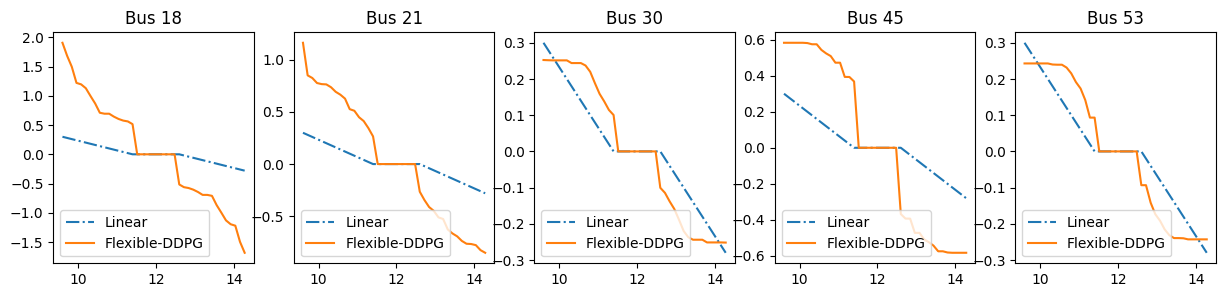

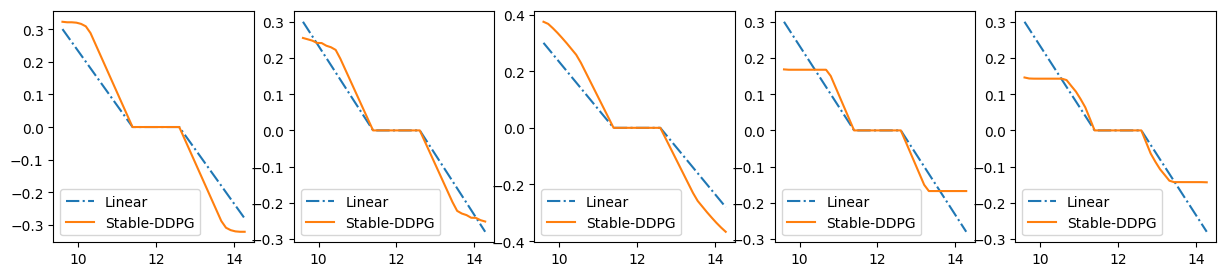

In [14]:
plot_policy(agent_policy_net, topology)
plot_safe_net(safe_agent_net)

### Flexible NN Contoller

In [23]:
### test our controller
voltage = []
q = []
cost = []
success_list = []
fail_list = []
entire_list = []
control_cost = []
reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list.append((episode,step))
            logger.success('episode {} stable at {} steps',success_list[-1][0], success_list[-1][1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list.append(episode_reward)
    control_cost.append(episode_control)

    if (not done) and (abnormal_stop == False):
        entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list))
logger.info('total fail episode is {}', len(fail_list))
logger.info('number of finished at entire episode is {}', len(entire_list))

2023-08-17 11:39:40.865 | SUCCESS  | __main__:<module>:46 - episode 0 stable at 3 steps
2023-08-17 11:39:41.008 | SUCCESS  | __main__:<module>:46 - episode 1 stable at 1 steps
2023-08-17 11:39:41.252 | SUCCESS  | __main__:<module>:46 - episode 2 stable at 3 steps
2023-08-17 11:39:41.490 | SUCCESS  | __main__:<module>:46 - episode 3 stable at 3 steps
2023-08-17 11:39:41.686 | SUCCESS  | __main__:<module>:46 - episode 4 stable at 2 steps
2023-08-17 11:39:42.135 | SUCCESS  | __main__:<module>:46 - episode 5 stable at 7 steps
2023-08-17 11:39:42.197 | SUCCESS  | __main__:<module>:46 - episode 6 stable at 0 steps
2023-08-17 11:39:43.131 | SUCCESS  | __main__:<module>:46 - episode 7 stable at 23 steps
2023-08-17 11:39:43.537 | SUCCESS  | __main__:<module>:46 - episode 8 stable at 9 steps
2023-08-17 11:39:43.645 | SUCCESS  | __main__:<module>:46 - episode 9 stable at 1 steps
2023-08-17 11:39:43.980 | SUCCESS  | __main__:<module>:46 - episode 10 stable at 7 steps
2023-08-17 11:39:44.248 | SUCC

In [16]:
success_list = np.array(success_list)
print('average recovery step is:')
print(np.mean(success_list[:,1]))
print(np.std(success_list[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost))
print(np.std(control_cost))


average recovery step is:
3.964
5.354876655909079
average reactive power cost is:
18.598515946409925
45.564450611884325


In [17]:
### test our controller without topology change
voltage_ = []
q_ = []
cost_ = []
success_list_ = []
fail_list_ = []
entire_list_ = []
control_cost_ = []
reward_list_ = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = 1/env.topology_init
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list_.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage_ violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list_.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list_.append((episode,step))
            logger.success('stable at {}',success_list_[-1])
            break

        voltage_.append(state)

        q_.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost_.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list_.append(episode_reward)
    control_cost_.append(episode_control)

    if (not done) and (abnormal_stop == False):
        entire_list_.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list_))
logger.info('total fail episode is {}', len(fail_list_))
logger.info('number of finished at entire episode is {}', len(entire_list_))

2023-08-17 10:45:32.224 | SUCCESS  | __main__:<module>:47 - stable at (0, 3)
2023-08-17 10:45:32.369 | SUCCESS  | __main__:<module>:47 - stable at (1, 1)
2023-08-17 10:45:32.688 | SUCCESS  | __main__:<module>:47 - stable at (2, 4)
2023-08-17 10:45:32.938 | SUCCESS  | __main__:<module>:47 - stable at (3, 3)
2023-08-17 10:45:33.171 | SUCCESS  | __main__:<module>:47 - stable at (4, 3)
2023-08-17 10:45:33.544 | SUCCESS  | __main__:<module>:47 - stable at (5, 6)
2023-08-17 10:45:33.673 | SUCCESS  | __main__:<module>:47 - stable at (6, 1)
2023-08-17 10:45:34.562 | SUCCESS  | __main__:<module>:47 - stable at (7, 21)
2023-08-17 10:45:35.055 | SUCCESS  | __main__:<module>:47 - stable at (8, 10)
2023-08-17 10:45:35.162 | SUCCESS  | __main__:<module>:47 - stable at (9, 1)
2023-08-17 10:45:35.517 | SUCCESS  | __main__:<module>:47 - stable at (10, 6)
2023-08-17 10:45:35.779 | SUCCESS  | __main__:<module>:47 - stable at (11, 5)
2023-08-17 10:45:35.961 | SUCCESS  | __main__:<module>:47 - stable at (1

In [18]:
success_list_ = np.array(success_list_)
print('average recovery step is:')
print(np.mean(success_list_[:,1]))
print(np.std(success_list_[:,1]))
print('average reactive power cost is:')
print(np.mean(control_cost_))
print(np.std(control_cost_))

average recovery step is:
4.138
5.458475611377228
average reactive power cost is:
19.37143518665911
47.29514518699861


### baseline

In [19]:
### test the base line controller
num_agent = 5
voltage = []
q = []
cost = []
base_succ_list = []
base_fail_list = []
base_entire_list = []
base_control_cost = []
base_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        state1 = np.asarray(state-env.vmax)
        state2 = np.asarray(env.vmin-state)
        d_v = (np.maximum(state1, 0)-np.maximum(state2, 0)).reshape((num_agent,1))
        
        action = (last_action - 10*d_v)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            base_succ_list.append((episode,step))
            logger.success('stable at {}',base_succ_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    base_control_cost.append(episode_control)
    base_reward_list.append(episode_reward)
    
    if (not done) and (abnormal_stop == False):
        base_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(base_succ_list))
logger.info('total fail episode is {}', len(base_fail_list))
logger.info('number of finished at entire episode is {}', len(base_entire_list))

2023-08-17 10:48:00.861 | SUCCESS  | __main__:<module>:45 - stable at (0, 49)
2023-08-17 10:48:01.114 | SUCCESS  | __main__:<module>:45 - stable at (1, 11)
2023-08-17 10:48:02.401 | SUCCESS  | __main__:<module>:45 - stable at (2, 77)
2023-08-17 10:48:03.030 | SUCCESS  | __main__:<module>:45 - stable at (3, 39)
2023-08-17 10:48:03.655 | SUCCESS  | __main__:<module>:45 - stable at (4, 39)
2023-08-17 10:48:05.116 | SUCCESS  | __main__:<module>:45 - stable at (5, 94)
2023-08-17 10:48:05.237 | SUCCESS  | __main__:<module>:45 - stable at (6, 6)
2023-08-17 10:48:06.640 | SUCCESS  | __main__:<module>:45 - stable at (7, 91)
2023-08-17 10:48:08.401 | SUCCESS  | __main__:<module>:45 - stable at (8, 119)
2023-08-17 10:48:08.710 | SUCCESS  | __main__:<module>:45 - stable at (9, 19)
2023-08-17 10:48:09.856 | SUCCESS  | __main__:<module>:45 - stable at (10, 74)
2023-08-17 10:48:10.357 | SUCCESS  | __main__:<module>:45 - stable at (11, 32)
2023-08-17 10:48:10.675 | SUCCESS  | __main__:<module>:45 - st

In [20]:
base_succ_list = np.array(base_succ_list)
print('average recovery step is:')
print(np.mean(base_succ_list[:,1]))
print(np.std(base_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(base_control_cost))
print(np.std(base_control_cost))


average recovery step is:
38.996
30.405130882796737
average reactive power cost is:
179.86729404351289
320.07161326604796


### Safe DDPG

In [21]:
### test the safe policy net
num_agent = 5
safe_voltage = []
safe_q = []
safe_cost = []
safe_succ_list = []
safe_fail_list = []
safe_entire_list = []
safe_contorl_cost = []
safe_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_topo(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(num_agent):
            action_agent = safe_agent_net[i].get_action(torch.cuda.FloatTensor([state[i]]).float().reshape(1,1))
            action.append(action_agent)
        
        action = last_action - 5*np.asarray(action).reshape((num_agent, 1))
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            safe_succ_list.append((episode,step))
            logger.success('stable at {}',safe_succ_list[-1])
            break
        safe_voltage.append(state)

        safe_q.append(action)

        state = next_state
        
        episode_reward += reward
        
        safe_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    safe_contorl_cost.append(episode_control)
    safe_reward_list.append(episode_reward)

    if (not done) and (abnormal_stop == False):
        safe_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(safe_succ_list))
logger.info('total fail episode is {}', len(safe_fail_list))
logger.info('number of finished at entire episode is {}', len(safe_entire_list))


2023-08-17 11:00:25.726 | SUCCESS  | __main__:<module>:46 - stable at (0, 32)
2023-08-17 11:00:25.942 | SUCCESS  | __main__:<module>:46 - stable at (1, 5)
2023-08-17 11:00:27.550 | SUCCESS  | __main__:<module>:46 - stable at (2, 53)
2023-08-17 11:00:28.210 | SUCCESS  | __main__:<module>:46 - stable at (3, 23)
2023-08-17 11:00:28.859 | SUCCESS  | __main__:<module>:46 - stable at (4, 21)
2023-08-17 11:00:30.679 | SUCCESS  | __main__:<module>:46 - stable at (5, 66)
2023-08-17 11:00:30.722 | SUCCESS  | __main__:<module>:46 - stable at (6, 0)
2023-08-17 11:00:32.582 | SUCCESS  | __main__:<module>:46 - stable at (7, 63)
2023-08-17 11:00:35.216 | SUCCESS  | __main__:<module>:46 - stable at (8, 83)
2023-08-17 11:00:35.529 | SUCCESS  | __main__:<module>:46 - stable at (9, 10)
2023-08-17 11:00:36.980 | SUCCESS  | __main__:<module>:46 - stable at (10, 51)
2023-08-17 11:00:37.502 | SUCCESS  | __main__:<module>:46 - stable at (11, 18)
2023-08-17 11:00:37.821 | SUCCESS  | __main__:<module>:46 - stab

In [22]:
safe_succ_list = np.array(safe_succ_list)
print('average recovery step is:')
print(np.mean(safe_succ_list[:,1]))
print(np.std(safe_succ_list[:,1]))
print('average reactive power cost is:')
print(np.mean(safe_contorl_cost))
print(np.std(safe_contorl_cost))

average recovery step is:
23.936
22.702773046480466
average reactive power cost is:
118.53361508707587
222.21759778969923
